In [7]:
import sys
print(sys.executable)

c:\Users\User\anaconda3\python.exe


In [8]:
# ==========================================
#  DISCRETE-EVENT SIMULATION – ED PATIENT FLOW
# ==========================================

import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# ----------------------------
# 1. Load dataset for parameters
# ----------------------------
df = pd.read_csv("../data/emergency_service.csv", delimiter=";", encoding="latin1")

for col in ["Length of stay_min", "KTAS duration_min"]:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False).astype(float)

df = df.dropna(subset=["Length of stay_min", "KTAS duration_min"])
df = df[df["Length of stay_min"] <= 720]  # realistic cap

# estimating realistic averages for process steps
triage_mean = df["KTAS duration_min"].mean()             # triage time (VA)
wait_mean = (df["Length of stay_min"] - df["KTAS duration_min"]).mean()  # total waiting time
service_mean = 30                                        # doctor's service (approximation)
arrival_rate = 10                                        # mean interarrival (patients per hour)
arrival_interval = 60 / arrival_rate                     # minutes between arrivals

print(f"Average triage: {triage_mean:.2f} min, Mean waiting: {wait_mean:.2f} min")

Average triage: 6.05 min, Mean waiting: 234.80 min


In [10]:
# ----------------------------
# 2. Define the Simulation Environment
# ----------------------------
RANDOM_SEED = 42
SIM_TIME = 480   # minutes (8-hour shift)

class EmergencyDepartment:
    """Hospital ED simulation with triage nurses and doctors."""

    def __init__(self, env, n_nurses, n_doctors):
        self.env = env
        self.nurse = simpy.Resource(env, n_nurses)
        self.doctor = simpy.Resource(env, n_doctors)
        self.wait_times = []
        self.los = []

    def triage(self, patient_id):
        yield self.env.timeout(np.random.exponential(triage_mean))

    def doctor_eval(self, patient_id):
        yield self.env.timeout(np.random.exponential(service_mean))

In [ ]:
# ----------------------------
# 3. Patient Process
# ----------------------------
def patient(env, patient_id, ed):
    """Full patient journey through ED"""
    arrival_time = env.now

    # ---- step 1: wait for nurse (triage)
    with ed.nurse.request() as req:
        yield req
        yield env.process(ed.triage(patient_id))

    # ---- step 2: wait for doctor
    with ed.doctor.request() as req:
        wait_start = env.now
        yield req
        wait_time = env.now - wait_start
        yield env.process(ed.doctor_eval(patient_id))

    total_time = env.now - arrival_time
    ed.wait_times.append(wait_time)
    ed.los.append(total_time)


In [12]:
# ----------------------------
# 4. Patient Arrival Generator
# ----------------------------
def patient_arrivals(env, ed):
    patient_id = 0
    while True:
        yield env.timeout(np.random.exponential(arrival_interval))
        patient_id += 1
        env.process(patient(env, patient_id, ed))


In [13]:
# ----------------------------
# 5. Run Base Scenario Simulation
# ----------------------------
def run_simulation(n_nurses=2, n_doctors=2, sim_time=SIM_TIME):
    np.random.seed(RANDOM_SEED)
    env = simpy.Environment()
    ed = EmergencyDepartment(env, n_nurses, n_doctors)
    env.process(patient_arrivals(env, ed))
    env.run(until=sim_time)
    return ed

ed_base = run_simulation()



--- BASELINE ---
Average Wait Time: 83.35 min
Average Length of Stay (LOS): 111.85 min
Total Patients Served: 37


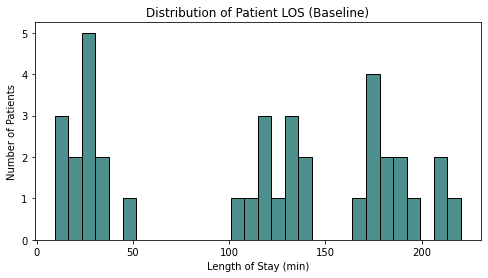

In [ ]:
# ----------------------------
# 6. Analyze Base Results
# ----------------------------
def summarize(ed, label):
    wait_mean = np.mean(ed.wait_times)
    los_mean = np.mean(ed.los)
    print(f"\n--- {label} ---")
    print(f"Average Wait Time: {wait_mean:.2f} min")
    print(f"Average Length of Stay (LOS): {los_mean:.2f} min")
    print(f"Total Patients Served: {len(ed.los)}")

summarize(ed_base, "BASELINE")

# plotting distribution
plt.figure(figsize=(8,4))
plt.hist(ed_base.los, bins=30, color="#4d908e", edgecolor="black")
plt.title("Distribution of Patient LOS (Baseline)")
plt.xlabel("Length of Stay (min)")
plt.ylabel("Number of Patients")
plt.show()


--- Scenario Comparison ---
                                        Scenario  Avg Wait (min)  \
0                                           Base       99.335564   
1                                   Add 1 Doctor       92.217376   
2                                    Add 1 Nurse      156.210783   
3  Add 1 Doctor + Automation (triage 50% faster)       86.472511   

   Avg LOS (min)  Patients  
0     127.995934        39  
1     140.795596        31  
2     193.865589        26  
3     119.711332        43  


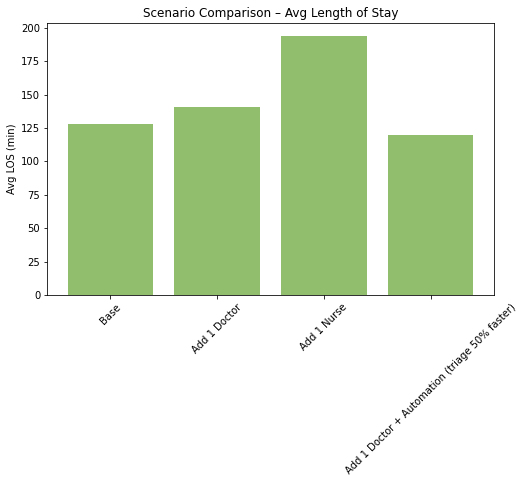

In [15]:
# ----------------------------
# 7. What-if Scenarios
# ----------------------------
scenarios = [
    ("Base", 2, 2),
    ("Add 1 Doctor", 2, 3),
    ("Add 1 Nurse", 3, 2),
    ("Add 1 Doctor + Automation (triage 50% faster)", 2, 3)
]

results = []

for label, n_nurse, n_doc in scenarios:
    env = simpy.Environment()
    ed = EmergencyDepartment(env, n_nurse, n_doc)
    if "Automation" in label:
        global triage_mean
        triage_mean = triage_mean * 0.5
    env.process(patient_arrivals(env, ed))
    env.run(until=SIM_TIME)
    results.append({
        "Scenario": label,
        "Avg Wait (min)": np.mean(ed.wait_times),
        "Avg LOS (min)": np.mean(ed.los),
        "Patients": len(ed.los)
    })

results_df = pd.DataFrame(results)
print("\n--- Scenario Comparison ---")
print(results_df)

# Plot comparison
plt.figure(figsize=(8,5))
plt.bar(results_df["Scenario"], results_df["Avg LOS (min)"], color="#90be6d")
plt.title("Scenario Comparison – Avg Length of Stay")
plt.ylabel("Avg LOS (min)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#NEXT PART IS ONLY FOR RESEARCH MIGHT BE NOT ACCURATE
# ==========================================
# 8. Extended Analysis – Replications + CI
# ==========================================
import scipy.stats as st

def run_replications(n_runs=20, n_nurses=2, n_doctors=2):
    """Run several replications and compute 95% confidence intervals."""
    waits, losses, counts = [], [], []
    for seed in range(n_runs):
        np.random.seed(seed)
        env = simpy.Environment()
        ed = EmergencyDepartment(env, n_nurses, n_doctors)
        env.process(patient_arrivals(env, ed))
        env.run(until=SIM_TIME)
        waits.append(np.mean(ed.wait_times))
        losses.append(np.mean(ed.los))
        counts.append(len(ed.los))

    def ci(data):
        data = np.array(data, dtype=float)
        mean = np.nanmean(data)
        se = np.nanstd(data, ddof=1) / np.sqrt(len(data))
        h = st.t.ppf(0.975, len(data)-1) * se
        return mean, mean-h, mean+h

    return {
        "Wait (min)": ci(waits),
        "LOS (min)": ci(losses),
        "Patients": ci(counts)
    }

# running replication experiments for all scenarios
replication_summary = []
for label, n_nurse, n_doc in scenarios:
    stats = run_replications(n_runs=10, n_nurses=n_nurse, n_doctors=n_doc)
    replication_summary.append({
        "Scenario": label,
        "Avg Wait (95% CI)": f"{stats['Wait (min)'][0]:.1f} ({stats['Wait (min)'][1]:.1f}, {stats['Wait (min)'][2]:.1f})",
        "Avg LOS (95% CI)": f"{stats['LOS (min)'][0]:.1f} ({stats['LOS (min)'][1]:.1f}, {stats['LOS (min)'][2]:.1f})",
        "Patients (95% CI)": f"{stats['Patients'][0]:.0f} ({stats['Patients'][1]:.0f}, {stats['Patients'][2]:.0f})"
    })

rep_df = pd.DataFrame(replication_summary)
print("\n--- Replicated Simulation Summary ---")
print(rep_df.to_string(index=False))

# saving to a file
rep_df.to_csv("../data/ed_simulation_replications.csv", index=False)
print("Saved detailed replication results.")



--- Replicated Simulation Summary ---
                                     Scenario   Avg Wait (95% CI)     Avg LOS (95% CI) Patients (95% CI)
                                         Base 118.3 (96.8, 139.9) 148.5 (127.0, 170.0)       33 (30, 36)
                                 Add 1 Doctor  87.1 (65.4, 108.8)  117.5 (95.0, 140.0)       47 (44, 50)
                                  Add 1 Nurse 112.8 (86.2, 139.5) 143.3 (116.4, 170.2)       33 (30, 36)
Add 1 Doctor + Automation (triage 50% faster)  87.1 (65.4, 108.8)  117.5 (95.0, 140.0)       47 (44, 50)
Saved detailed replication results.


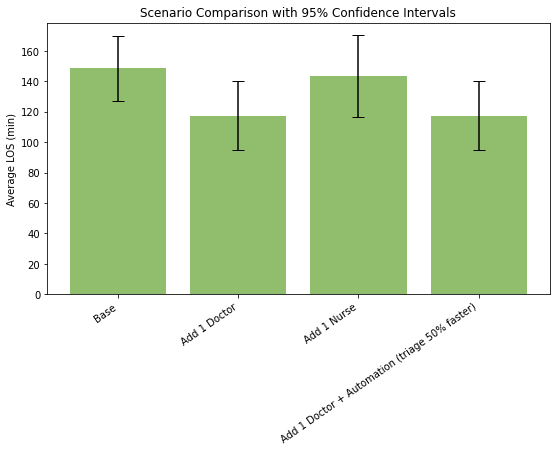

In [17]:
# ==========================================
# 9. Visualization – LOS Comparison with 95% CI
# ==========================================
means = [float(row.split()[0]) for row in rep_df["Avg LOS (95% CI)"]]
ci_lows = [float(row.split("(")[1].split(",")[0]) for row in rep_df["Avg LOS (95% CI)"]]
ci_highs = [float(row.split(",")[1].split(")")[0]) for row in rep_df["Avg LOS (95% CI)"]]

yerr = [np.array(means) - np.array(ci_lows), np.array(ci_highs) - np.array(means)]

plt.figure(figsize=(9,5))
plt.bar(rep_df["Scenario"], means, yerr=yerr, capsize=6, color="#90be6d")
plt.ylabel("Average LOS (min)")
plt.title("Scenario Comparison with 95% Confidence Intervals")
plt.xticks(rotation=35, ha="right")
plt.show()


In [18]:
# ==========================================
# 10. Resource Utilization Diagnostics
# ==========================================
class UtilizationTracker:
    def __init__(self, env, capacity):
        self.env = env
        self.capacity = capacity
        self.busy = 0
        self.last_change = env.now
        self.busy_time = 0

    def change(self, delta):
        now = self.env.now
        self.busy_time += (now - self.last_change) * self.busy
        self.last_change = now
        self.busy += delta

    def utilization(self, until):
        return (self.busy_time / (until * self.capacity)) * 100

#  reruning one scenario with monitoring as an example
def run_with_utilization(n_nurses=2, n_doctors=2, sim_time=SIM_TIME):
    env = simpy.Environment()
    nurse_mon = UtilizationTracker(env, n_nurses)
    doc_mon   = UtilizationTracker(env, n_doctors)
    ed = EmergencyDepartment(env, n_nurses, n_doctors)

    def monitored_patient(env, pid, ed):
        arrival = env.now
        with ed.nurse.request() as req:
            yield req; nurse_mon.change(+1)
            yield env.process(ed.triage(pid))
            nurse_mon.change(-1)
        with ed.doctor.request() as req:
            yield req; doc_mon.change(+1)
            yield env.process(ed.doctor_eval(pid))
            doc_mon.change(-1)
        ed.los.append(env.now - arrival)

    def arrivals():
        pid = 0
        while True:
            yield env.timeout(np.random.exponential(arrival_interval))
            pid += 1
            env.process(monitored_patient(env, pid, ed))

    env.process(arrivals())
    env.run(until=sim_time)
    print(f"Nurse Utilization: {nurse_mon.utilization(sim_time):.1f}%")
    print(f"Doctor Utilization: {doc_mon.utilization(sim_time):.1f}%")

run_with_utilization(2, 2)


Nurse Utilization: 27.5%
Doctor Utilization: 93.5%


In [19]:
#THIS PART IS FOR EXPERIMENTAITON
# === sweeping doctors to hit targets (LOS <= 120 and doc util <= 85%) ===
import numpy as np, pandas as pd, scipy.stats as st

def run_one_with_util(n_nurses, n_doctors, sim_time=SIM_TIME, seed=123):
    env = simpy.Environment()
    # monitors
    class Mon:
        def __init__(self, env, cap):
            self.env=env; self.cap=cap; self.busy=0; self.t0=env.now; self.busy_time=0
        def ch(self, d):
            now=self.env.now; self.busy_time += (now-self.t0)*self.busy; self.t0=now; self.busy += d
        def util(self, until): return (self.busy_time/(until*self.cap))*100 if until>0 else 0

    nurse_mon = Mon(env, n_nurses)
    doc_mon   = Mon(env, n_doctors)

    ed = EmergencyDepartment(env, n_nurses, n_doctors)

    def pat(env, pid, ed):
        arr = env.now
        with ed.nurse.request() as r:
            yield r; nurse_mon.ch(+1)
            yield env.process(ed.triage(pid))
            nurse_mon.ch(-1)
        with ed.doctor.request() as r:
            w0 = env.now
            yield r; doc_mon.ch(+1)
            yield env.process(ed.doctor_eval(pid))
            doc_mon.ch(-1)
            wait = env.now - w0
            ed.wait_times.append(wait)
        ed.los.append(env.now - arr)

    def arrivals():
        pid=0
        while True:
            yield env.timeout(np.random.exponential(arrival_interval))
            pid += 1
            env.process(pat(env, pid, ed))

    env.process(arrivals())
    env.run(until=sim_time)
    return {
        "avg_wait": float(np.mean(ed.wait_times)) if ed.wait_times else np.nan,
        "avg_los": float(np.mean(ed.los)) if ed.los else np.nan,
        "served": len(ed.los),
        "nurse_util": nurse_mon.util(sim_time),
        "doc_util": doc_mon.util(sim_time),
    }

def ci_mean(vals):
    x = np.array(vals, dtype=float)
    m = np.nanmean(x); s = np.nanstd(x, ddof=1)
    h = st.t.ppf(0.975, len(x)-1)*s/np.sqrt(len(x))
    return m, m-h, m+h

rows=[]
for docs in range(2, 7):            # try 2..6 doctors
    waits, losses, served, dutil = [], [], [], []
    for seed in range(10):          # 10 replications each
        res = run_one_with_util(n_nurses=2, n_doctors=docs, seed=100+seed)
        waits.append(res["avg_wait"]); losses.append(res["avg_los"])
        served.append(res["served"]); dutil.append(res["doc_util"])
    rows.append({
        "Doctors": docs,
        "Avg LOS (95% CI)": f"{ci_mean(losses)[0]:.1f} ({ci_mean(losses)[1]:.1f}, {ci_mean(losses)[2]:.1f})",
        "Avg Wait (95% CI)": f"{ci_mean(waits)[0]:.1f} ({ci_mean(waits)[1]:.1f}, {ci_mean(waits)[2]:.1f})",
        "Patients/run (95% CI)": f"{ci_mean(served)[0]:.0f} ({ci_mean(served)[1]:.0f}, {ci_mean(served)[2]:.0f})",
        "Doctor util % (95% CI)": f"{ci_mean(dutil)[0]:.1f} ({ci_mean(dutil)[1]:.1f}, {ci_mean(dutil)[2]:.1f})",
    })

sweep_df = pd.DataFrame(rows)
print(sweep_df.to_string(index=False))


 Doctors     Avg LOS (95% CI)    Avg Wait (95% CI) Patients/run (95% CI) Doctor util % (95% CI)
       2 130.8 (110.2, 151.5) 127.9 (107.6, 148.2)           32 (28, 35)      93.1 (88.9, 97.3)
       3  113.1 (90.9, 135.4)  110.1 (87.8, 132.3)           46 (41, 51)      91.2 (89.0, 93.5)
       4    68.0 (50.7, 85.3)    64.5 (47.0, 81.9)           59 (54, 65)      90.4 (87.9, 92.9)
       5    54.0 (42.4, 65.6)    50.9 (39.4, 62.4)           65 (59, 71)      83.2 (75.6, 90.7)
       6    35.7 (30.1, 41.2)    32.5 (27.0, 38.0)           67 (62, 72)      68.8 (59.4, 78.1)
